In [32]:
import os
import sys
from datetime import datetime
from collections import OrderedDict
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
# Add the folder path to the Python path
folder_path = '../pyshbundle/'
sys.path.append(folder_path)

In [33]:
from pyshbundle.hydro import TWSCalc
from pyshbundle.io import extract_SH_data, extract_deg1_coeff_tn13, extract_deg2_3_coeff_tn14
from pyshbundle.viz_utils import plot_calendar_months

In [34]:
source='jpl'
path_sh = "../data/JPL_input/"
# source='csr'
# path_sh = "../data/CSR_input/"
# source='itsg'
# path_sh = "../sample_input_data/ITSG_input/"

path_tn14 = "../pyshbundle/data/JPL_TN_files/TN-14_C30_C20_GSFC_SLR.txt"    # Path to TN14
path_tn13 = "../pyshbundle/data/JPL_TN_files/TN-13_GEOC_JPL_RL06.txt"       # Path to TN13

In [35]:
files = os.listdir(path_sh)
if str.upper(source) == 'ITSG':
    file_paths = [path_sh + file for file in files if os.path.splitext(file)[1] == '.gfc'];
else:
    file_paths = [path_sh + file for file in files if os.path.splitext(file)[1] == '.gz'];

In [36]:
extracted_data={} 
for file_path in file_paths:
    # file_data = read_sh(file_path, source=source)
    file_data = extract_SH_data(file_path, source=source)
    if file_data['time_coverage_start']:
        # Convert time_coverage_start to a datetime object and then format it as yyyy-mm
        if source == 'itsg':
            start_date = datetime.strptime(file_data['time_coverage_start'][-7:], '%Y-%m').strftime('%Y-%m')
        else:
            start_date = datetime.strptime(file_data['time_coverage_start'], '%Y-%m-%dT%H:%M:%S.%f').strftime('%Y-%m')
        # Use the formatted date as the key
        extracted_data[start_date] = file_data['coefficients']


# Time Sort the dictionary by keys (dates)
sorted_data = OrderedDict(sorted(extracted_data.items()));

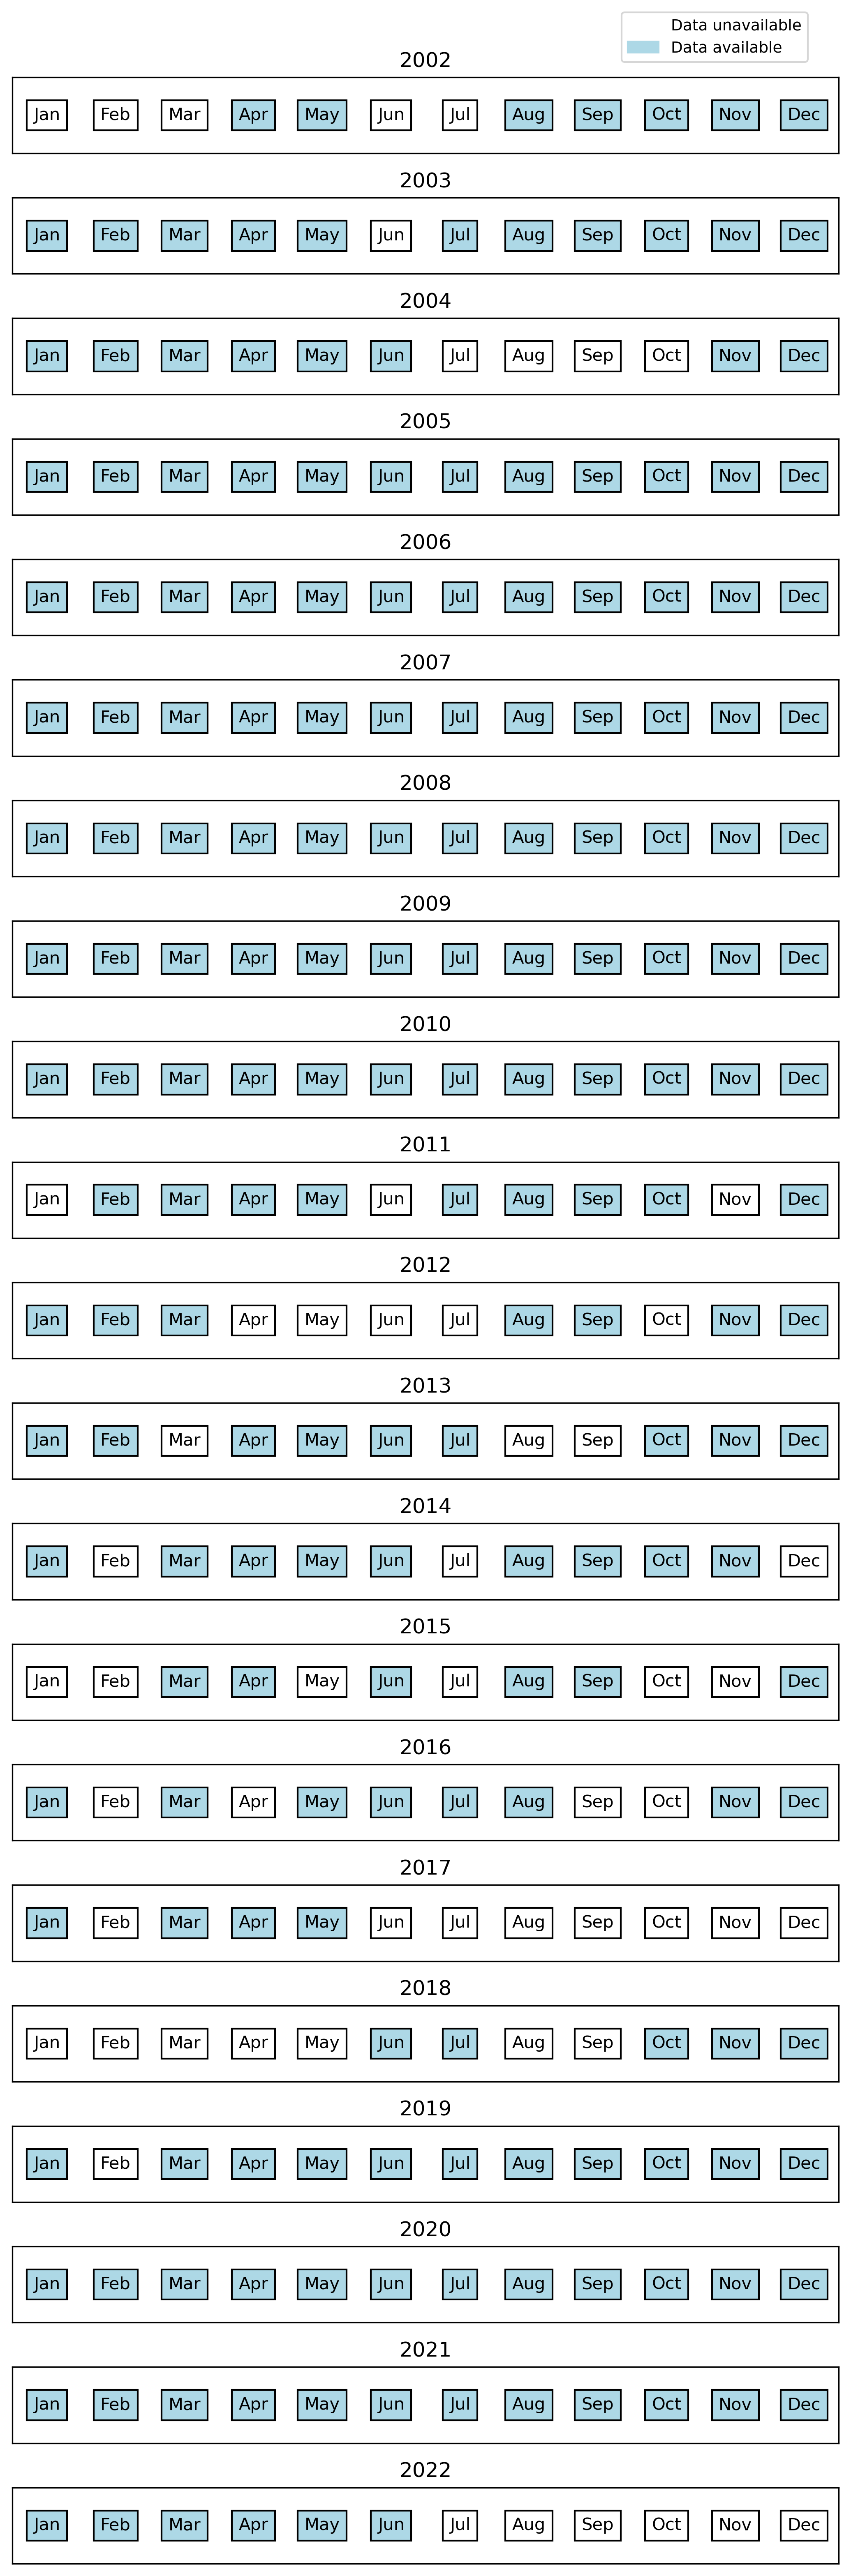

In [37]:
datetime_object = sorted_data.keys()

plot_calendar_months(datetime_object)

In [38]:
print(list(sorted_data.keys())[0:5], '\n')             # dicitonary for each year-month, printing only first 5
print(list(sorted_data['2002-04'].keys())[0:5], '\n')  # dictionary for each degree and order, , printing only first 5
print(sorted_data['2002-04'][(2,0)].keys(), '\n')      # dictionary with the data for repective year-month, degree and order
print('Clm value for (degree, order)=(2,0) is:', sorted_data['2002-04'][(2,0)]['Clm'])

['2002-04', '2002-05', '2002-08', '2002-09', '2002-10'] 

[(2, 0), (2, 1), (2, 2), (3, 0), (3, 1)] 

dict_keys(['Clm', 'Slm', 'Clm_sdev', 'Slm_sdev']) 

Clm value for (degree, order)=(2,0) is: -0.000484169317396


In [39]:
temp_tn14 = extract_deg2_3_coeff_tn14(path_tn14);

In [40]:
print('Keys of the TN14 replacement dictionary', list(temp_tn14.keys())[0:5],)        # dicitonary for each year-month, , printing only first 5
print('Keys of dictionary for year-month 2002-4', temp_tn14['2002-04'].keys())  # dictionary for c20, c30 coefficients for each year-month
print('For 2002-04 :',  '\n'
      'C20 is:', temp_tn14['2002-04']['c20'], '\n'
      'C30 is:',temp_tn14['2002-04']['c30'])

Keys of the TN14 replacement dictionary ['2002-04', '2002-05', '2002-08', '2002-09', '2002-10']
Keys of dictionary for year-month 2002-4 dict_keys(['year_frac_start', 'mjd_start', 'c20', 'c20_mean_diff', 'c20_sigma', 'c30', 'c30_mean_diff', 'c30_sigma', 'mjd_end', 'year_frac_end'])
For 2002-04 : 
C20 is: -0.00048416932630052 
C30 is: None


In [41]:
for date_key in temp_tn14.keys():
    if date_key in sorted_data.keys():
        sorted_data[date_key][(2,0)]['Clm'] = temp_tn14[date_key]['c20']
        if temp_tn14[date_key]['c30'] is not None:
            sorted_data[date_key][(3,0)]['Clm'] = temp_tn14[date_key]['c30'];

In [42]:
temp_tn13=extract_deg1_coeff_tn13(path_tn13)

In [43]:
print('Keys of the TN13 replacement dictionary', list(temp_tn13.keys())[0:5],)        # dicitonary for each year-month, printing only first 5
print('Keys of dictionary for year-month 2002-4', temp_tn13[('2002-04', 1, 0)].keys())  # dictionary for c20, c30 coefficients for each year-month
print('For 2002-04 :',  '\n'
       'C10 is:', temp_tn13[('2002-04', 1, 0)]['Clm'], '\n'
       'S10 is:', temp_tn13[('2002-04', 1, 0)]['Slm'], '\n'
       'C11 is:', temp_tn13[('2002-04', 1, 1)]['Clm'], '\n'
       'C11 is:', temp_tn13[('2002-04', 1, 1)]['Slm'])

Keys of the TN13 replacement dictionary [('2002-04', 1, 0), ('2002-04', 1, 1), ('2002-05', 1, 0), ('2002-05', 1, 1), ('2002-08', 1, 0)]
Keys of dictionary for year-month 2002-4 dict_keys(['degree', 'order', 'Clm', 'Slm', 'Clm_sdev', 'Slm_sdev', 'epoch_begin', 'epoch_end'])
For 2002-04 : 
C10 is: 4.935091508e-10 
S10 is: 0.0 
C11 is: 2.407968956e-10 
C11 is: -6.808848629e-11


In [44]:
if str.upper(source)=='JPL':
    for key in sorted_data:
        sorted_data[key][(0, 0)] = {'Clm': 0.0, 'Slm': 0.0, 'Clm_sdev': 0.0, 'Slm_sdev': 0.0}
        sorted_data[key][(1, 0)] = {'Clm': 0.0, 'Slm': 0.0, 'Clm_sdev': 0.0, 'Slm_sdev': 0.0}
        sorted_data[key][(1, 1)] = {'Clm': 0.0, 'Slm': 0.0, 'Clm_sdev': 0.0, 'Slm_sdev': 0.0};
else: pass

In [45]:
for date_key in temp_tn13.keys():
    if date_key[0] in sorted_data.keys():
        # print(date_key)
        sorted_data[date_key[0]][(date_key[1], date_key[2])]['Clm'] = temp_tn13[date_key]['Clm']
        sorted_data[date_key[0]][(date_key[1], date_key[2])]['Slm'] = temp_tn13[date_key]['Slm']
        sorted_data[date_key[0]][(date_key[1], date_key[2])]['Clm_sdev'] = temp_tn13[date_key]['Clm_sdev']
        sorted_data[date_key[0]][(date_key[1], date_key[2])]['Slm_sdev'] = temp_tn13[date_key]['Slm_sdev'];

In [46]:
max_degree=np.max([degree for date in sorted_data.keys() for degree, order in sorted_data[date].keys()])
max_order=np.max([order for date in sorted_data.keys() for degree, order in sorted_data[date].keys()])
number_of_months=len(sorted_data.keys())
print('The maximum degree & order in data is:' , max_degree, '&', max_order)
print('Number of months for which data is available:', number_of_months)

The maximum degree & order in data is: 96 & 96
Number of months for which data is available: 196


In [47]:
sc_mat=np.zeros([number_of_months, max_degree+1, 2*(max_degree+1)], dtype=np.double)

for index, key in enumerate(sorted_data.keys()):
    temp=sorted_data[key]
    for l in range(0,max_degree+1):
        for m in range(0,l+1):
            '''uncomment these two lines to see how the elements are being accessed from the dictionary'''
            # print(l,m)
            # print(temp[(l,m)]['Clm'])
            sc_mat[index, l, max_degree+m+1]=temp[(l,m)]['Clm']
            sc_mat[index, l, max_degree-m]=temp[(l,m)]['Slm']
    del temp

In [48]:
sc_mat=np.delete(sc_mat, max_degree, axis=2);

In [49]:
SH_long_mean_jpl = np.load('../pyshbundle/data/long_mean/SH_long_mean_jpl.npy')    # load the long term mean SH coeffs---> JPL 
SH_long_mean_csr = np.load('../pyshbundle/data/long_mean/SH_long_mean_csr.npy')    # load the long term mean SH coeffs---> CSR
SH_long_mean_itsg = np.load('../pyshbundle/data/long_mean/SH_long_mean_itsg.npy')    # load the long term mean SH coeffs---> ITSG
delta_sc=np.ones_like(sc_mat)*np.nan
if source== 'jpl':
    delta_sc = sc_mat -   SH_long_mean_jpl
    # delta_sc = sc_mat -   sc_mat.mean(axis=0)      # Remove the mean of the data
elif source== 'csr':
    delta_sc = sc_mat - SH_long_mean_csr
elif source== 'itsg':
    delta_sc = sc_mat - SH_long_mean_itsg

In [50]:
delta_sc.shape

(196, 97, 193)

In [51]:
import numpy as np
import pandas as pd

def linear_trend(y, x):
    """Calculate linear trend via least squares (no weighting, pure slope)."""
    mask = np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan
    # Fit: y = a + b * x
    A = np.vstack([np.ones_like(x[mask]), x[mask]]).T
    try:
        result = np.linalg.lstsq(A, y[mask], rcond=None)[0]
        return result[1]  # Return the slope (trend)
    except Exception:
        return np.nan

# Build time in decimal years (adjust start date as needed)
start_date = pd.Timestamp('2002-04-01')
n_months = delta_sc.shape[0]
time_index = pd.date_range(start=start_date, periods=n_months, freq='M')
time_num = (time_index.year + time_index.dayofyear / 365.25) - (start_date.year + start_date.dayofyear / 365.25)

lmax = delta_sc.shape[1] - 1
m_center = lmax    # index in array where m=0
trend_matrix = np.full((lmax+1, 2*lmax+1), np.nan)

# Calculate trend for each element, regardless of SH meaning
for l in range(lmax+1):
    for m_idx in range(2*lmax+1):
        y = delta_sc[:, l, m_idx]
        if np.all(np.isnan(y)):
            continue
        trend = linear_trend(y, time_num)
        trend_matrix[l, m_idx] = trend

# trend_matrix now has shape (97, 193),
# with the trend for each stored SH matrix element as in your matrix photo
print("trend_matrix shape:", trend_matrix.shape)

/tmp/ipykernel_1291/1077360967.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_index = pd.date_range(start=start_date, periods=n_months, freq='M')


trend_matrix shape: (97, 193)


In [52]:
trend_matrix

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
        -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
        -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
       [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
         2.02613892e-12, -7.25083396e-13,  6.96307618e-14]],
      shape=(97, 193))

In [53]:
# Expand trend_matrix to shape (1, 97, 193):
trend_sc_3d = trend_matrix[None, :, :]  # shape (1, 97, 193)
trend_sc_3d

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
         -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
         -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
        [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
          2.02613892e-12, -7.25083396e-13,  6.96307618e-14]]],
      shape=(1, 97, 193))

In [56]:
import xarray as xr
import numpy as np

# Suppose you already have trend_sc_3d, shape (1, 97, 193)
# Create coordinate arrays for dimensions
time_coord = [0]  # singleton time coordinate (e.g., an index or a date string)
degree_coord = np.arange(97)  # degrees 0 to 96
order_coord = np.arange(193)  # orders -96 to +96 mapped as indices 0 to 192

# Convert numpy array to xarray DataArray
da = xr.DataArray(
    data=trend_sc_3d,
    dims=['time', 'degree', 'order'],
    coords={
        'time': time_coord,
        'degree': degree_coord,
        'order': order_coord
    },
    name='trend_sc_jpl'
)

# Convert DataArray to Dataset for more flexibility (optional)
ds = da.to_dataset()

# Save to NetCDF
ds.to_netcdf('trend_sc_3d_jpl1.nc', mode='w')

print("Saved trend_sc_3d to trend_sc_3d_jpl1.nc")

Saved trend_sc_3d to trend_sc_3d_jpl1.nc


In [57]:
trend_sc_3d = xr.open_dataset('trend_sc_3d_jpl1.nc')
trend_sc_3d

<xarray.Dataset> Size: 152kB
Dimensions:       (time: 1, degree: 97, order: 193)
Coordinates:
  * time          (time) int64 8B 0
  * degree        (degree) int64 776B 0 1 2 3 4 5 6 7 ... 90 91 92 93 94 95 96
  * order         (order) int64 2kB 0 1 2 3 4 5 6 ... 187 188 189 190 191 192
Data variables:
    trend_sc_jpl  (time, degree, order) float64 150kB ...

In [58]:
trend_sc_3d.trend_sc_jpl.values

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
         -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
         -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
        [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
          2.02613892e-12, -7.25083396e-13,  6.96307618e-14]]],
      shape=(1, 97, 193))

In [59]:
from pyshbundle.shutils import Gaussian
import matplotlib.pyplot as plt

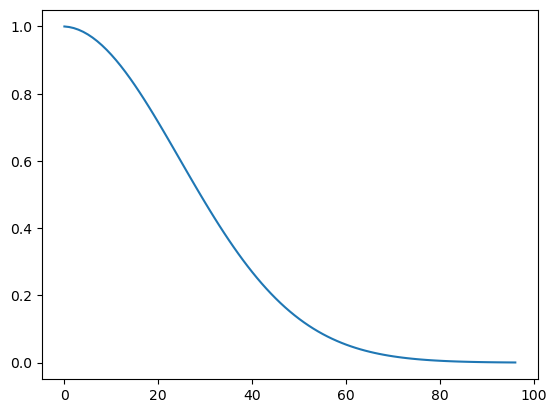

In [60]:
temp=Gaussian(L=96, cap=300);
plt.plot(temp)

In [61]:
# print('Kindly enter the following parameters based on your application')
# lmax = int(input("Enter lmax: "))
# gs = int(input("Enter grid size: "))
# half_rad_gf = int(input("Enter half radius of Gaussian filter: "))
# print("lmax , grid size & half raduius of gaussian filter are : ", lmax ,", " , gs,", ",half_rad_gf)
lmax,gs,half_rad_gf=96, 0.5, 300

In [62]:
trend_matrix

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
        -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
        -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
       [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
         2.02613892e-12, -7.25083396e-13,  6.96307618e-14]],
      shape=(97, 193))

In [63]:
# Expand trend_matrix to shape (1, 97, 193):
trend_sc_3d = trend_matrix[None, :, :]  # shape (1, 97, 193)
trend_sc_3d

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00, -9.34802581e-13, ...,
         -4.14544606e-13,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -7.08406224e-13, -1.57527857e-13, ...,
         -2.93557617e-13, -5.33979976e-13,  0.00000000e+00],
        [ 1.27521050e-12,  1.68145391e-12, -3.00289064e-12, ...,
          2.02613892e-12, -7.25083396e-13,  6.96307618e-14]]],
      shape=(1, 97, 193))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.94it/s]


CPU times: user 203 ms, sys: 0 ns, total: 203 ms
Wall time: 425 ms


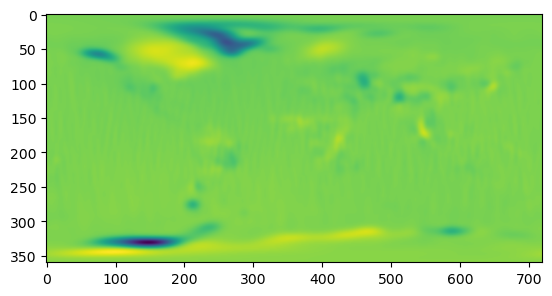

In [64]:
%%time
# tws_fields = TWSCalc(delta_sc,lmax, gs,half_rad_gf, number_of_months)
tws_fields = TWSCalc(trend_sc_3d, lmax, gs, half_rad_gf, 1)

In [65]:
tws_fields.shape

(1, 360, 720)

In [66]:
tws_fields = np.float32(tws_fields)

In [67]:
lon = np.arange(-180, 180, gs)
lat = np.arange(89.5, -90.5, -gs)

# lon = np.arange(0, 360, gs)
# lat = np.arange(-90, 90, gs)

dates = pd.to_datetime(list(sorted_data.keys()), format='%Y-%m') \
    + pd.offsets.MonthEnd(0)  # .dt.strftime('%d-%m-%Y')

dates_single = dates[:1]

ds = xr.Dataset(
    data_vars=dict(
        tws=(["time", "lat", "lon"], tws_fields, {"units": "mm"})
    ),
    coords={
        "time": dates_single,
        "lat": lat,
        "lon": lon
    },
    attrs=dict(
        description="Global gridded TWS Anomaly corresponding to long term (2004-2010) mean",
        units="mm"
    ),
)
ds

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 1, lat: 360, lon: 720)
Coordinates:
  * time     (time) datetime64[ns] 8B 2002-04-30
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * lon      (lon) float64 6kB -180.0 -179.5 -179.0 -178.5 ... 178.5 179.0 179.5
Data variables:
    tws      (time, lat, lon) float32 1MB -0.8538 -0.8547 -0.8556 ... 7.94 7.942
Attributes:
    description:  Global gridded TWS Anomaly corresponding to long term (2004...
    units:        mm

In [68]:
import xarray as xr
import numpy as np

# Assume tws_fields has shape (1, 360, 720) after synthesis
# Squeeze out the singleton time dimension to get 2D data
tws_2d = tws_fields.squeeze(axis=0)  # shape becomes (360, 720)

lon = np.arange(-180, 180, gs)
lat = np.arange(89.5, -90.5, -gs)

ds_2d = xr.Dataset(
    data_vars=dict(
        tws=(["lat", "lon"], tws_2d, {"units": "mm"})
    ),
    coords={
        "lat": lat,
        "lon": lon
    },
    attrs=dict(description="Global gridded TWS Anomaly trend map(2D)", units="mm we/yr"),
)

ds_2d

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 360, lon: 720)
Coordinates:
  * lat      (lat) float64 3kB 89.5 89.0 88.5 88.0 ... -88.5 -89.0 -89.5 -90.0
  * lon      (lon) float64 6kB -180.0 -179.5 -179.0 -178.5 ... 178.5 179.0 179.5
Data variables:
    tws      (lat, lon) float32 1MB -0.8538 -0.8547 -0.8556 ... 7.939 7.94 7.942
Attributes:
    description:  Global gridded TWS Anomaly trend map(2D)
    units:        mm we/yr

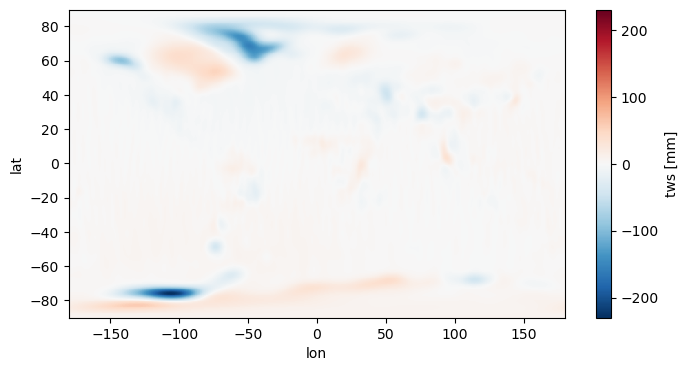

In [69]:
ds_2d['tws'].plot(figsize=(8, 4))

In [70]:
ds_2d.to_netcdf('../examples/Rigd_Earth_EWH_trend_JPL300GF_ohne_love0.5ohneGIA.nc')